# Regression Analysis: California Housing

**Dataset:** California Housing (via `sklearn.datasets`)

**Objective:** Build a regression workflow to predict median house values. Compare multiple models: Linear Regression, SVR, and Random Forest.

---


### Step 1: Setup & Data Loading


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset
california = fetch_california_housing()
df = pd.DataFrame(california.data, columns=california.feature_names)
df['Target_MedHouseVal'] = california.target

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target_MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### Step 2: Exploratory Data Analysis (EDA)

We check for missing values and visualize the target distribution.


Missing Values:
MedInc                0
HouseAge              0
AveRooms              0
AveBedrms             0
Population            0
AveOccup              0
Latitude              0
Longitude             0
Target_MedHouseVal    0
dtype: int64


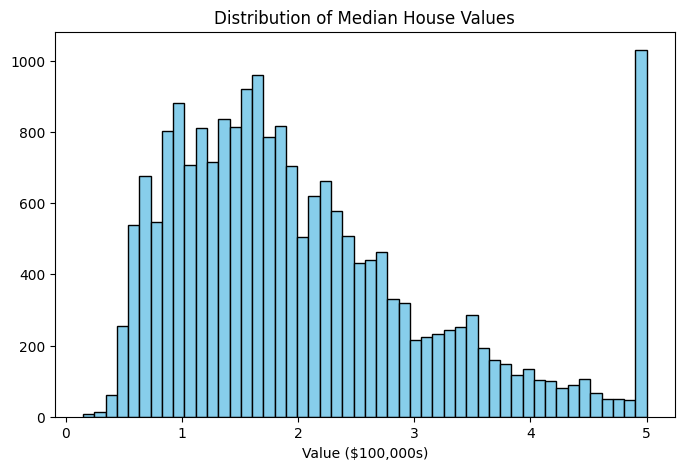

In [5]:
print("Missing Values:")
print(df.isna().sum())

plt.figure(figsize=(8, 5))
plt.hist(df['Target_MedHouseVal'], bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of Median House Values')
plt.xlabel('Value ($100,000s)')
plt.show()

### Step 3: Preprocessing & Splitting


In [6]:
X = df.drop('Target_MedHouseVal', axis=1)
y = df['Target_MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Step 4: Model Comparison

We train three models and compare their R² scores.


In [7]:
models = {
    "Linear Regression": LinearRegression(),
    "SVR": SVR(kernel='rbf'),
    "Random Forest": RandomForestRegressor(n_estimators=50, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results[name] = {'MSE': mse, 'R2': r2}

results_df = pd.DataFrame(results).T
results_df.sort_values(by='R2', ascending=False)

,MSE,R2
Random Forest,0.257003,0.803876
SVR,0.357004,0.727563
Linear Regression,0.555892,0.575788
